# Verification of the four-flux isotopomer labeling network

Curated reconstruction of Sec. 15.3.3 and Figure 15.4 of Mu F, Bauer AL, Faeder JR,
Hlavacek WS (2010), *Using systems biology techniques to determine metabolic fluxes and
metabolite pool sizes*, in **Handbook of Chemoinformatics Algorithms**, Chapman and
Hall/CRC, pp. 399–422.

Three checks are run.

1. **Model specification.** BioNetGen output from `four_flux_network_isotopomer_labeling_mu2010.bngl`
   is compared with `independent_mu2010.py`, which builds the same isotopomer balance
   equations by the *other* method the chapter reviews — the isotopomer mapping matrices
   of Eqs. 15.14–15.18 applied to the balances of Eqs. 15.19–15.34 — and shares nothing
   with the BNGL carbon fate maps.
2. **Closed form.** Both are compared with the isotopic steady state of the product,
   which can be written down exactly because the stoichiometric balances of
   Eqs. 15.4–15.7 hold.
3. **Reported data.** Both are compared with the four curves of Figure 15.4, recovered
   from the vector geometry of the published panel by `digitize_mu2010.py` and committed
   as `reference/mu2010_fig15_4_digitized.csv`.

Check 3 also decides a reading of the printed BioNetGen input file that the printed text
leaves ambiguous: whether the substrate pool `S` carries the feed composition from
$t = 0$, or starts unlabeled and relaxes to it. Only the first reproduces the published
figure.

In [1]:
import os
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

MODEL_DIR = Path.cwd()
if MODEL_DIR.name != "four_flux_network_isotopomer_labeling_mu2010":
    MODEL_DIR = Path("models/four_flux_network_isotopomer_labeling_mu2010").resolve()
REFERENCE = MODEL_DIR / "reference"
sys.path.insert(0, str(MODEL_DIR))

import independent_mu2010 as ind  # noqa: E402

BNGPATH = Path(os.environ.get("BNGPATH", Path.home() / "Simulations/BioNetGen-2.9.3"))
BNG2 = BNGPATH / "BNG2.pl"
assert BNG2.exists(), f"BioNetGen executable not found: {BNG2}"
print("BioNetGen:", BNGPATH, "version", (BNGPATH / "VERSION").read_text().strip())

MODEL = "four_flux_network_isotopomer_labeling_mu2010.bngl"

# The four simulation protocols of the BNGL file and the Figure 15.4 curve each draws.
PROTOCOLS = {
    "ode":         ("solid",    "pool size of M2 = 1"),
    "ode_m2low":   ("dash-dot", "pool size of M2 = 0.5"),
    "ode_m2high":  ("dashed",   "pool size of M2 = 2"),
    "ode_altflux": ("dotted",   "v1 = 0.6, v2 = 0.4, v3 = 0.5, v4 = 0.3"),
}

# Figure 15.4 is drawn with 0.05 in P01 spanning 172.1 typographic points and every
# trajectory stroked at 0.75 pt, so one point of the printed panel is this much P01.
P01_PER_POINT = 0.05 / 172.1
STROKE_PT = 0.75

BioNetGen: /Users/wish/Simulations/BioNetGen-2.9.3 version 2.9.3


## Run BioNetGen

The BNGL file is copied into a scratch directory and run there, so verification cannot
overwrite the committed reference outputs. The results are then checked against those
outputs, which is the reproducibility criterion of `skills/bngl/rating.md` §2.

In [2]:
def read_gdat(path):
    with path.open() as fh:
        names = fh.readline().lstrip("#").split()
    values = np.atleast_2d(np.loadtxt(path))
    return pd.DataFrame(values, columns=names)


def run_bionetgen(model_name):
    source = MODEL_DIR / model_name
    with tempfile.TemporaryDirectory(prefix="mu2010_") as tmp:
        work = Path(tmp)
        shutil.copy2(source, work / source.name)
        env = os.environ.copy()
        env["BNGPATH"] = str(BNGPATH)
        done = subprocess.run(
            ["perl", str(BNG2), source.name],
            cwd=work, env=env, check=True, capture_output=True, text=True,
        )
        assert "ERROR" not in done.stdout, done.stdout
        stem = source.stem
        return {tag: read_gdat(work / f"{stem}_{tag}.gdat") for tag in PROTOCOLS}


bng = run_bionetgen(MODEL)

worst_ref = 0.0
for tag, frame in bng.items():
    committed = read_gdat(REFERENCE / f"{Path(MODEL).stem}_{tag}.gdat")
    assert list(committed.columns) == list(frame.columns)
    worst_ref = max(worst_ref, float(np.max(np.abs(committed.to_numpy() - frame.to_numpy()))))
print(f"fresh run vs committed reference/: max absolute difference {worst_ref:.3e}")

print("\npool totals held constant by the balances of Eqs. 15.4-15.7:")
for tag, frame in bng.items():
    drift = {c: float(np.ptp(frame[c])) for c in frame.columns if c.startswith("Obs_Tot_")}
    print(f"  {tag:12s} max drift over the run = {max(drift.values()):.2e}")

fresh run vs committed reference/: max absolute difference 0.000e+00

pool totals held constant by the balances of Eqs. 15.4-15.7:
  ode          max drift over the run = 6.27e-09
  ode_m2low    max drift over the run = 4.60e-08
  ode_m2high   max drift over the run = 1.19e-09
  ode_altflux  max drift over the run = 4.92e-08


## Check 1 — against the isotopomer mapping matrix construction

`independent_mu2010.py` integrates

$$V_S \frac{d\mathbf{I}_S}{dt} = v_S\,\mathbf{F} - (v_1+v_2)\,\mathbf{I}_S,\qquad
  V_{M_1}\frac{d\mathbf{I}_{M_1}}{dt} = v_1\,\mathrm{IMM}_{S>M_1}\mathbf{I}_S - (v_3+v_{M_1})\,\mathbf{I}_{M_1},$$
$$V_{M_2}\frac{d\mathbf{I}_{M_2}}{dt} = v_2\,\mathrm{IMM}_{S>M_2}\mathbf{I}_S - (v_4+v_{M_2})\,\mathbf{I}_{M_2},\qquad
  V_P\frac{d\mathbf{I}_P}{dt} = v_3\,\mathrm{IMM}_{M_1>P}\mathbf{I}_{M_1} + v_4\,\mathrm{IMM}_{M_2>P}\mathbf{I}_{M_2} - v_P\,\mathbf{I}_P,$$

with the four matrices of Eqs. 15.15–15.18 and $\mathbf{F}$ the feed composition. It never
touches BioNetGen, the generated network, or the BNGL fate maps.

One discrepancy inside the chapter has to be resolved to write these down. Eqs. 15.27–15.30
carry the $S \to M_2$ step without the carbon transposition, while Eq. 15.16, the carbon
transition diagram of Fig. 15.3, and the BNGL rule of Sec. 15.3.3 all carry it. The
transposition is the only route from a feed labeled at C1 to a product labeled at C2, so
without it $P_{01}$ would be identically zero and Figure 15.4 would be empty; Eq. 15.16 is
therefore the one implemented.

In [3]:
worst = {}
for tag, frame in bng.items():
    solution = ind.simulate(tag, frame["time"].to_numpy())
    errors = {
        name: float(np.max(np.abs(frame[name].to_numpy() - solution[name])))
        for name in ("P00", "P01", "P10", "P11")
    }
    worst[tag] = max(errors.values())
    print(f"{tag:12s} max |BNG - IMM|  " +
          "  ".join(f"{k}={v:.2e}" for k, v in errors.items()))
print(f"\nworst over all four protocols and all four isotopomers: {max(worst.values()):.3e}")

ode          max |BNG - IMM|  P00=1.48e-07  P01=7.35e-08  P10=7.35e-08  P11=0.00e+00
ode_m2low    max |BNG - IMM|  P00=1.01e-07  P01=7.73e-08  P10=2.63e-08  P11=0.00e+00
ode_m2high   max |BNG - IMM|  P00=1.55e-07  P01=4.11e-08  P10=1.14e-07  P11=0.00e+00
ode_altflux  max |BNG - IMM|  P00=1.47e-07  P01=3.52e-08  P10=1.12e-07  P11=0.00e+00

worst over all four protocols and all four isotopomers: 1.552e-07


## Check 2 — against the closed-form isotopic steady state

Because $v_S = v_1 + v_2$, $v_1 = v_{M_1} + v_3$, $v_2 = v_{M_2} + v_4$ and
$v_P = v_3 + v_4$, the steady state can be written down without integrating anything:
$S$ sits at the feed composition, each intermediate inherits it through its own mapping
matrix, and $v_P\mathbf{I}_P = v_3\mathbf{I}_{M_1} + v_4\mathbf{I}_{M_2}$. Pool sizes
cancel, which is the chapter's statement that pool size does not affect the steady-state
distribution — the three curves that differ only in $V_{M_2}$ must share a plateau.

In [4]:
rows = []
for tag, frame in bng.items():
    exact = ind.steady_state_P(tag)
    late = ind.simulate(tag, np.array([0.0, 2000.0]))["P"][:, -1]
    rows.append({
        "protocol": tag,
        "P01 at t=20 (BNG)": frame["P01"].iloc[-1],
        "P01 at t=2000": late[ind.I01],
        "P01 closed form": exact[ind.I01],
        "|difference|": abs(late[ind.I01] - exact[ind.I01]),
    })
table = pd.DataFrame(rows).set_index("protocol")
print(table.to_string(float_format=lambda v: f"{v:.9f}"))
assert table["|difference|"].max() < 1e-9
print("\nplateau of the three pool-size protocols:",
      f"{ind.steady_state_P('ode')[ind.I01]:.4f} for all three")
print("plateau of the redistributed-flux protocol:",
      f"{ind.steady_state_P('ode_altflux')[ind.I01]:.4f}"
      "  = v_v4 * f_label / v_vp")

             P01 at t=20 (BNG)  P01 at t=2000  P01 closed form  |difference|
protocol                                                                    
ode                0.049993948    0.050000000      0.050000000   0.000000000
ode_m2low          0.049999971    0.050000000      0.050000000   0.000000000
ode_m2high         0.049509962    0.050000000      0.050000000   0.000000000
ode_altflux        0.037474838    0.037500000      0.037500000   0.000000000

plateau of the three pool-size protocols: 0.0500 for all three
plateau of the redistributed-flux protocol: 0.0375  = v_v4 * f_label / v_vp


## Check 3 — against the published Figure 15.4

Figure 15.4 is line art, so the four trajectories were recovered from the vector geometry
of the panel rather than from pixels: `digitize_mu2010.py` re-renders the page as SVG with
poppler, applies each path's affine transform, samples its cubic Béziers, and calibrates on
the axis box of the same SVG, checking the result against the three interior x tick marks
and the four interior y tick marks. Each trajectory is identified by its stroke dash
pattern, which the caption maps onto a simulation condition.

The natural tolerance is the figure's own resolution. Its trajectories are stroked at
0.75 pt on an axis where the full $P_{01}$ range of 0.05 spans 172.1 pt, so one stroke
width is $2.2\times10^{-4}$ in $P_{01}$; deviations are reported in those units.

In [5]:
digitized = pd.read_csv(REFERENCE / "mu2010_fig15_4_digitized.csv")

rows = []
for tag, (style, condition) in PROTOCOLS.items():
    series = digitized[digitized["condition"] == tag].sort_values("time")
    t = series["time"].to_numpy()
    published = series["P01"].to_numpy()

    frame = bng[tag]
    spline = CubicSpline(frame["time"].to_numpy(), frame["P01"].to_numpy())
    # Bound the error the spline itself contributes, using the independent solution.
    grid = np.unique(t)
    spline_error = float(np.max(np.abs(spline(grid) - ind.simulate(tag, grid)["P01"])))

    curated = spline(t) - published
    lagged = ind.simulate_lagged_S(tag, grid)["P01"][np.searchsorted(grid, t)] - published
    rows.append({
        "protocol": tag,
        "Fig. 15.4 curve": style,
        "n": len(t),
        "median (stroke widths)": np.median(np.abs(curated)) / P01_PER_POINT / STROKE_PT,
        "max (stroke widths)": np.max(np.abs(curated)) / P01_PER_POINT / STROKE_PT,
        "lagged-S median": np.median(np.abs(lagged)) / P01_PER_POINT / STROKE_PT,
        "lagged-S max": np.max(np.abs(lagged)) / P01_PER_POINT / STROKE_PT,
        "spline error": spline_error,
    })

comparison = pd.DataFrame(rows).set_index("protocol")
print(comparison.to_string(float_format=lambda v: f"{v:.3g}"))

assert comparison["median (stroke widths)"].max() < 0.8, "curated model off the published curves"
assert comparison["max (stroke widths)"].max() < 3.5
assert comparison["lagged-S median"].min() > 3.0, "the two readings are not distinguishable"
print("\nThe curated model tracks every published curve to within a fraction of the "
      "figure's own stroke width.")
print("The reading in which S starts unlabeled misses them by tens of stroke widths and "
      "is rejected.")

            Fig. 15.4 curve    n  median (stroke widths)  max (stroke widths)  lagged-S median  lagged-S max  spline error
protocol                                                                                                                  
ode                   solid  601                   0.573                 2.67             10.4          46.1      2.87e-05
ode_m2low          dash-dot  601                   0.494                 2.08             23.5          57.7      9.21e-05
ode_m2high           dashed  801                   0.308                 1.33             11.7            30      1.05e-05
ode_altflux          dotted  601                   0.592                 1.93             3.83          30.3      1.53e-05

The curated model tracks every published curve to within a fraction of the figure's own stroke width.
The reading in which S starts unlabeled misses them by tens of stroke widths and is rejected.


## Figure

Panel (a) overlays the curated simulations, the independent isotopomer-mapping-matrix
solution, and the digitized published curves. Panel (b) is the residual against the
published curves with the figure's own stroke width shown for scale. Panel (c) shows all
four product isotopomer fractions for the reference protocol; $P_{11}$ stays at zero
because the feed is labeled at one carbon only.

max |P11| over the reference protocol: 0.0


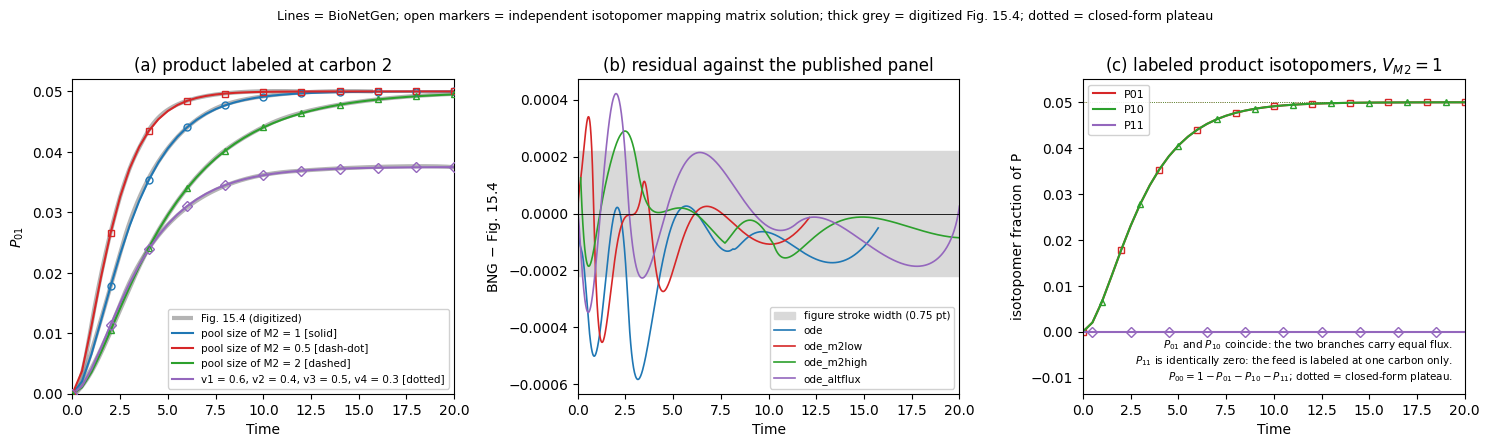

In [6]:
COLORS = {"ode": "#1f77b4", "ode_m2low": "#d62728",
          "ode_m2high": "#2ca02c", "ode_altflux": "#9467bd"}
MARKERS = {"ode": "o", "ode_m2low": "s", "ode_m2high": "^", "ode_altflux": "D"}

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4))

ax = axes[0]
for tag, (style, condition) in PROTOCOLS.items():
    frame = bng[tag]
    series = digitized[digitized["condition"] == tag].sort_values("time")
    ax.plot(series["time"], series["P01"], color="0.55", lw=3.0, alpha=0.65,
            solid_capstyle="butt", zorder=1,
            label="Fig. 15.4 (digitized)" if tag == "ode" else None)
    ax.plot(frame["time"], frame["P01"], color=COLORS[tag], lw=1.5, zorder=2,
            label=f"{condition} [{style}]")
    solution = ind.simulate(tag, frame["time"].to_numpy())
    ax.plot(frame["time"][::4], solution["P01"][::4], MARKERS[tag], mfc="none",
            mec=COLORS[tag], ms=5, zorder=3)
ax.set_xlabel("Time"), ax.set_ylabel(r"$P_{01}$")
ax.set_title("(a) product labeled at carbon 2")
ax.set_xlim(0, 20), ax.set_ylim(0, 0.052)
ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)

ax = axes[1]
band = P01_PER_POINT * STROKE_PT
ax.axhspan(-band, band, color="0.85", zorder=0, label="figure stroke width (0.75 pt)")
for tag in PROTOCOLS:
    series = digitized[digitized["condition"] == tag].sort_values("time")
    frame = bng[tag]
    spline = CubicSpline(frame["time"].to_numpy(), frame["P01"].to_numpy())
    ax.plot(series["time"], spline(series["time"].to_numpy()) - series["P01"].to_numpy(),
            color=COLORS[tag], lw=1.2, label=tag)
ax.axhline(0.0, color="k", lw=0.6)
ax.set_xlabel("Time"), ax.set_ylabel(r"BNG $-$ Fig. 15.4")
ax.set_title("(b) residual against the published panel")
ax.set_xlim(0, 20)
ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)

ax = axes[2]
frame = bng["ode"]
solution = ind.simulate("ode", frame["time"].to_numpy())
exact = ind.steady_state_P("ode")
for name, color, marker, offset in (("P01", "#d62728", "s", 0), ("P10", "#2ca02c", "^", 2),
                                    ("P11", "#9467bd", "D", 1)):
    ax.plot(frame["time"], frame[name], color=color, lw=1.5, label=name)
    ax.plot(frame["time"][offset::4], solution[name][offset::4], marker, mfc="none",
            mec=color, ms=5)
    ax.axhline(exact[("P00", "P01", "P10", "P11").index(name)], color=color, lw=0.6, ls=":")
ax.set_xlabel("Time"), ax.set_ylabel("isotopomer fraction of P")
ax.set_title("(c) labeled product isotopomers, $V_{M2}=1$")
ax.set_xlim(0, 20), ax.set_ylim(-0.0135, 0.055)
ax.text(0.97, 0.03,
        "$P_{01}$ and $P_{10}$ coincide: the two branches carry equal flux.\n"
        "$P_{11}$ is identically zero: the feed is labeled at one carbon only.\n"
        r"$P_{00} = 1 - P_{01} - P_{10} - P_{11}$; dotted = closed-form plateau.",
        transform=ax.transAxes, va="bottom", ha="right", fontsize=7.5)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
print("max |P11| over the reference protocol:", float(np.max(np.abs(frame["P11"]))))

fig.suptitle("Lines = BioNetGen; open markers = independent isotopomer mapping matrix "
             "solution; thick grey = digitized Fig. 15.4; dotted = closed-form plateau",
             fontsize=9, y=1.005)
fig.tight_layout()
fig.savefig(MODEL_DIR / "verify_mu2010.png", dpi=160, bbox_inches="tight")
plt.show()

## Summary

| Check | Against | Result |
|---|---|---|
| Reproducibility | committed `reference/*.gdat` | exact |
| Model specification | isotopomer mapping matrices, Eqs. 15.14–15.34 | agreement to 2e-7 over four protocols and four isotopomers, the accuracy of BioNetGen's default ODE tolerances |
| Closed form | analytic isotopic steady state | plateau reproduced to <1e-9; 0.05 for the three pool-size protocols and 0.0375 for the redistributed-flux protocol |
| Reported data | digitized Figure 15.4, four curves | median deviation well under one stroke width of the published panel |

The published figure also settles the ambiguity in the printed input file: the substrate
pool carries the feed composition from $t=0$, and the alternative reading in which it
starts unlabeled is off by tens of stroke widths.